## Analyse Exploratoire des Données 


| **Variable** | **Description** |
|---------------|-----------------|
| **Internet Provider** | Fournisseur d'accès Internet. |
| **Monthly Cost (USD)** | Coût mensuel de l'abonnement. |
| **Download Speed (Mbps)** | Vitesse de téléchargement. |
| **Upload Speed (Mbps)** | Vitesse d'envoi. |
| **Latency (ms)** | Temps de réponse de la connexion. |
| **Monthly Data Consumption (GB)** | Consommation mensuelle de données. |
| **Signal Strength (dBm)** | Qualité du signal réseau. |
| **Connection Stability (%)** | Stabilité de la connexion. |
| **Satisfaction Score** | Niveau de satisfaction (1 à 5). |

| Type | Variables |
|--------|----------|
| Variables continues | Age, Monthly_Cost_USD, Download_Speed_Mbps, Upload_Speed_Mbps, Latency_ms, Monthly_Data_Consumption_GB, Signal_Strength_dBm, Connection_Stability_Percent |
| Variables catégorielles/discrete | Country, Region_Type, Gender, Network_Type, Internet_Provider, Satisfaction_Score |

In [51]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import scipy as stats
from scipy.stats import pearsonr
import scipy.stats
import scipy.optimize

In [52]:
df=pd.read_excel("internet_telecom_dataset_5000.xlsx")
df

,ID,Country,Region_Type,Age,Gender,Network_Type,Internet_Provider,Monthly_Cost_USD,Download_Speed_Mbps,Upload_Speed_Mbps,Latency_ms,Monthly_Data_Consumption_GB,Signal_Strength_dBm,Connection_Stability_Percent,Satisfaction_Score
0,1,Morocco,Suburban,21,Male,2G,Vodafone,6.38,0.12,0.04,404,1.35,-103,59.8,1.0
1,2,Morocco,Urban,67,Male,3G,AT&T,9.20,2.39,1.40,239,4.14,-92,75.2,1.9
2,3,Morocco,Urban,62,Female,4G,SFR,21.40,96.15,15.45,35,49.49,-73,85.1,4.2
3,4,Morocco,Urban,21,Male,Fiber,Maroc Telecom,68.30,170.92,269.88,13,734.11,-74,94.3,4.6
4,5,Morocco,Urban,62,Male,5G,Inwi,32.57,680.56,49.28,16,170.14,-86,91.6,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Laos,Rural,73,Female,Fiber,Inwi,98.99,562.94,635.40,16,657.23,-65,86.2,5.4
4996,4997,Laos,Suburban,52,Female,4G,Verizon,26.99,33.82,16.54,62,29.11,-72,84.9,3.7
4997,4998,Laos,Urban,36,Female,4G,T-Mobile,11.00,24.03,19.24,80,50.15,-60,77.1,3.2
4998,4999,Laos,Urban,52,Male,Fiber,Inwi,79.38,389.26,596.53,18,506.96,-70,96.8,5.5


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            5000 non-null   int64  
 1   Country                       5000 non-null   str    
 2   Region_Type                   5000 non-null   str    
 3   Age                           5000 non-null   int64  
 4   Gender                        5000 non-null   str    
 5   Network_Type                  5000 non-null   str    
 6   Internet_Provider             5000 non-null   str    
 7   Monthly_Cost_USD              5000 non-null   float64
 8   Download_Speed_Mbps           5000 non-null   float64
 9   Upload_Speed_Mbps             5000 non-null   float64
 10  Latency_ms                    5000 non-null   int64  
 11  Monthly_Data_Consumption_GB   5000 non-null   float64
 12  Signal_Strength_dBm           5000 non-null   int64  
 13  Connection_Sta

In [54]:
df.isnull().sum()

ID                              0
Country                         0
Region_Type                     0
Age                             0
Gender                          0
Network_Type                    0
Internet_Provider               0
Monthly_Cost_USD                0
Download_Speed_Mbps             0
Upload_Speed_Mbps               0
Latency_ms                      0
Monthly_Data_Consumption_GB     0
Signal_Strength_dBm             0
Connection_Stability_Percent    0
Satisfaction_Score              0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.describe()

,ID,Age,Monthly_Cost_USD,Download_Speed_Mbps,Upload_Speed_Mbps,Latency_ms,Monthly_Data_Consumption_GB,Signal_Strength_dBm,Connection_Stability_Percent,Satisfaction_Score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,46.055200,36.848062,242.865706,116.798168,72.665200,203.650662,-73.989000,83.668900,3.962640
std,1443.520003,17.194269,23.359585,271.072794,177.514472,117.459845,232.200491,13.480936,10.524503,1.279012
min,1.000000,16.000000,3.000000,0.050000,0.020000,2.000000,0.120000,-105.000000,45.000000,1.000000
25%,1250.750000,31.000000,18.317500,33.545000,13.620000,16.000000,40.002500,-85.000000,77.600000,3.100000
50%,2500.500000,46.000000,32.035000,90.715000,34.800000,35.000000,100.510000,-74.000000,86.000000,3.900000
75%,3750.250000,61.000000,52.852500,433.827500,143.552500,75.000000,320.220000,-63.000000,91.700000,5.100000
max,5000.000000,75.000000,99.970000,999.050000,799.560000,899.000000,999.760000,-45.000000,99.000000,6.600000


L'analyse descriptive des 5000 clients montre un âge moyen de 46 ans, un coût mensuel moyen de 36,85 USD, une consommation moyenne de 203,65 Go, une bonne stabilité de connexion (83,67 %) et une satisfaction moyenne de 3,96, tandis que les vitesses Internet, la latence et la consommation de données présentent une forte variabilité entre les utilisateurs, avec la présence de valeurs extrêmes.

## Analyse univarié

### Variables Continues :

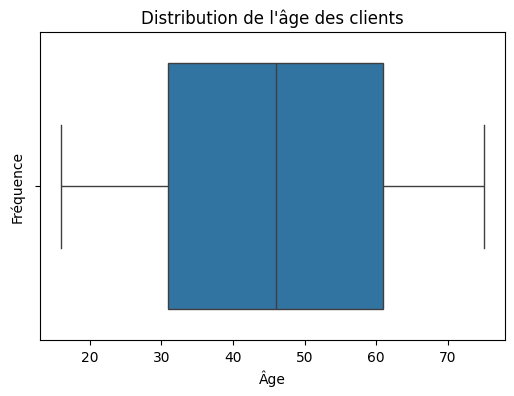

In [57]:
# variable continue
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Age")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.title("Distribution de l'âge des clients")
plt.show()

Le graphique montre une distribution de l'âge très homogène et parfaitement centrée, où la moitié des clients a entre 31 et 61 ans avec un âge médian de 46 ans.

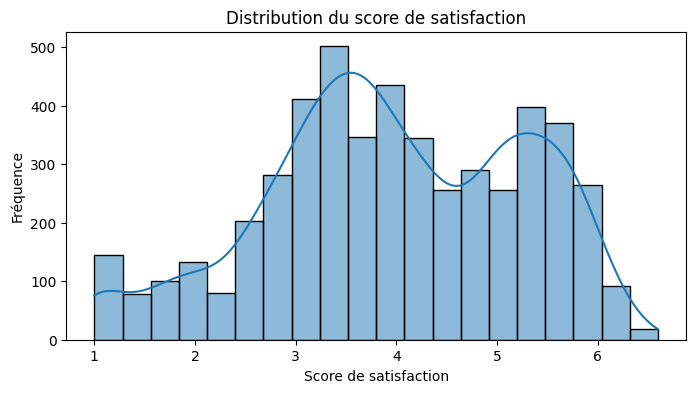

In [58]:
# variable continue
plt.figure(figsize=(8,4))
sns.histplot(df["Satisfaction_Score"], bins=20, kde=True)
plt.xlabel("Score de satisfaction")
plt.ylabel("Fréquence")
plt.title("Distribution du score de satisfaction")
plt.show()

Le graphique montre que la satisfaction se divise en deux groupes principaux : la majorité des clients donne une note moyenne autour de 3,5, tandis qu'un second groupe important se dit très satisfait autour de 5,5.

In [59]:
df["Download_Speed_Mbps"].describe()

count    5000.000000
mean      242.865706
std       271.072794
min         0.050000
25%        33.545000
50%        90.715000
75%       433.827500
max       999.050000
Name: Download_Speed_Mbps, dtype: float64

### Variables descrètes :

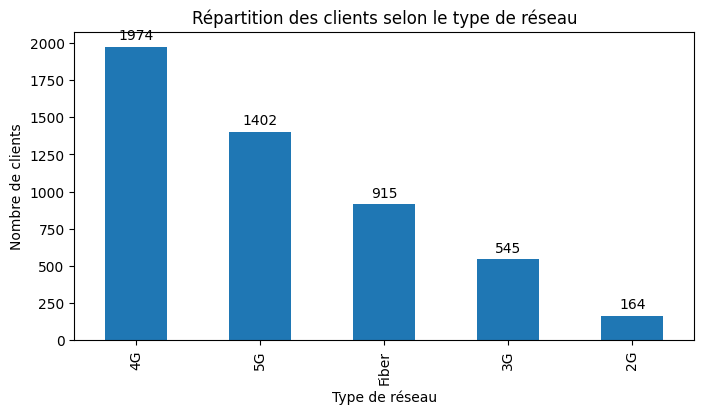

In [60]:
# variable discrète
plt.figure(figsize=(8,4))
ax=df["Network_Type"].value_counts().plot(kind="bar")
ax.bar_label(ax.containers[0], padding=3)
plt.xlabel("Type de réseau")
plt.ylabel("Nombre de clients")
plt.title("Répartition des clients selon le type de réseau")
plt.show()

Le graphique montre que le réseau 4G est le plus utilisé par les clients (près de 2000 utilisateurs), suivi de la 5G, de la Fibre et de la 3G, tandis que la 2G reste le type de réseau le moins adopté

In [61]:
# variable discrète
df["Internet_Provider"].value_counts()#.plot(kind="bar")

Internet_Provider
Verizon           551
Free              512
Inwi              509
Vodafone          507
Maroc Telecom     497
T-Mobile          496
AT&T              489
Orange            485
SFR               484
Telecom Global    470
Name: count, dtype: int64

### Variable discrète et continue :

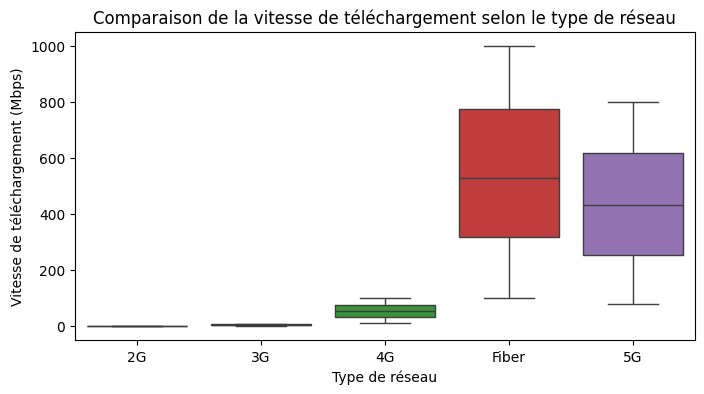

In [62]:
# variable discrète et continue
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Network_Type", y="Download_Speed_Mbps", hue="Network_Type")
plt.xlabel("Type de réseau")
plt.ylabel("Vitesse de téléchargement (Mbps)")
plt.title("Comparaison de la vitesse de téléchargement selon le type de réseau")
plt.show()

Le graphique montre que la Fibre et la 5G offrent les vitesses de téléchargement les plus élevées et les plus variables, tandis que les réseaux 4G, 3G et 2G affichent des performances nettement inférieures et très limitées.

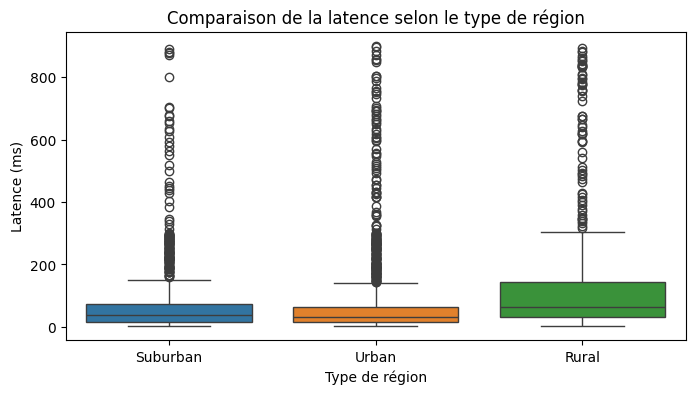

In [63]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Region_Type", y="Latency_ms", hue="Region_Type")
plt.xlabel("Type de région")
plt.ylabel("Latence (ms)")
plt.title("Comparaison de la latence selon le type de région")
plt.show()

Le graphique indique que les régions rurales présentent la latence la plus élevée et la plus dispersée (médiane proche de 100 ms), tandis que les zones urbaines et périurbaines bénéficient d'une meilleure connexion avec une latence globalement plus faible et stable.

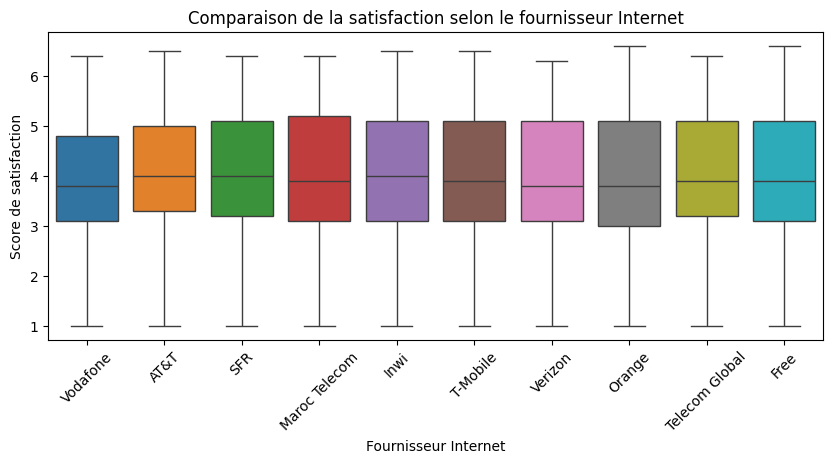

In [64]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Internet_Provider", y="Satisfaction_Score", hue="Internet_Provider")
plt.xlabel("Fournisseur Internet")
plt.ylabel("Score de satisfaction")
plt.title("Comparaison de la satisfaction selon le fournisseur Internet")
plt.xticks(rotation=45)
plt.show()

Le graphique démontre que le score de satisfaction des clients reste extrêmement similaire et homogène d'un opérateur à l'autre.

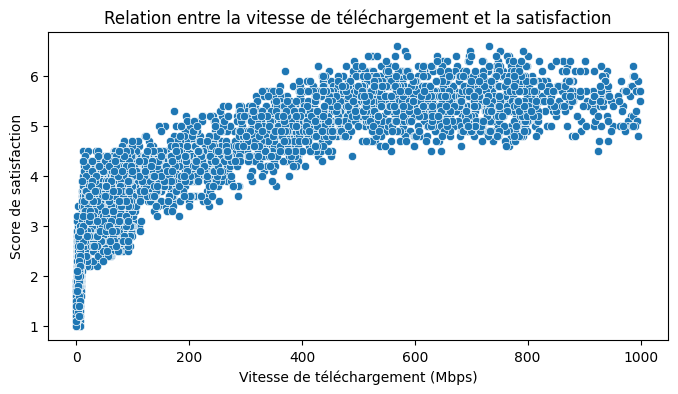

In [65]:
# continue + continue 
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,
                x="Download_Speed_Mbps",
                y="Satisfaction_Score")
plt.xlabel("Vitesse de téléchargement (Mbps)")
plt.ylabel("Score de satisfaction")
plt.title("Relation entre la vitesse de téléchargement et la satisfaction")
plt.show()

L'analyse met en évidence une relation positive entre la vitesse de téléchargement et la satisfaction des clients. Toutefois, au-delà de 500 Mbps, la satisfaction se stabilise, indiquant que des vitesses plus élevées n'apportent plus d'amélioration significative.

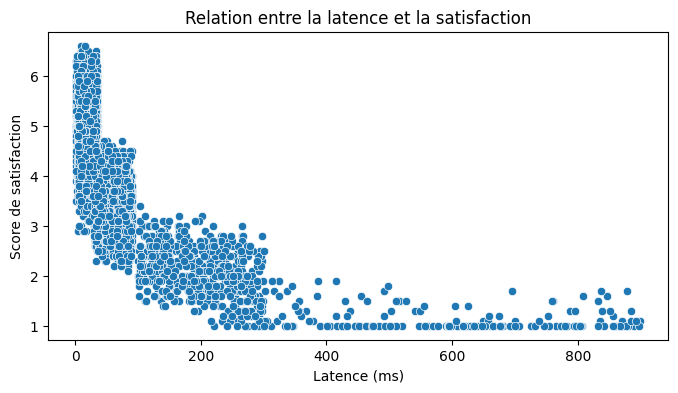

In [66]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Latency_ms",y="Satisfaction_Score")
plt.xlabel("Latence (ms)")
plt.ylabel("Score de satisfaction")
plt.title("Relation entre la latence et la satisfaction")
plt.show()

Le graphique montre une relation inverse par paliers où le score de satisfaction des clients chute brutalement dès que la latence augmente, passant d'un niveau maximal pour une latence proche de 0 ms à un niveau de insatisfaction totale (score bloqué autour de 1) dès que la latence dépasse 300 ms.

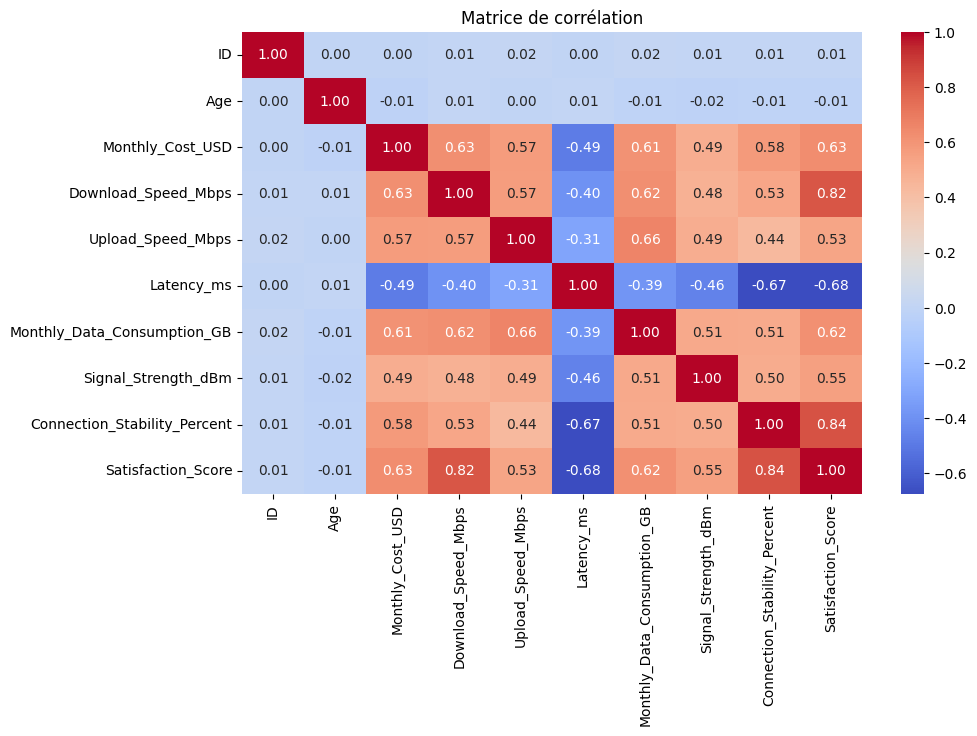

In [78]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Matrice de corrélation")
plt.show()

La matrice indique que la satisfaction des clients est fortement liée à la stabilité de la connexion (0,84) et à la vitesse de téléchargement (0,82), tandis qu'elle subit un impact négatif marqué de la latence (-0,68), confirmant que les performances techniques du réseau dictent l'expérience utilisateur, alors que l'âge et l'identifiant n'ont absolument aucune influence.

In [68]:
# Importation des bibliothèques
import pandas as pd
from scipy.stats import f_oneway

# Création des groupes par fournisseur
groups = [
    group["Satisfaction_Score"].dropna()
    for _, group in df.groupby("Internet_Provider")
]

# Test ANOVA
f_stat, p_value = f_oneway(*groups)

print("Statistique F :", round(f_stat, 3))
print("p-value :", round(p_value, 4))

# Interprétation
alpha = 0.05

if p_value < alpha:
    print("Conclusion : Il existe une différence significative entre les fournisseurs Internet.")
else:
    print("Conclusion : Aucune différence significative entre les fournisseurs.")

Statistique F : 1.144
p-value : 0.3275
Conclusion : Aucune différence significative entre les fournisseurs.


In [69]:
from scipy.stats import pearsonr

variables = [
    "Monthly_Cost_USD",
    "Download_Speed_Mbps",
    
]

for var in variables:
    corr, p = pearsonr(df[var], df["Satisfaction_Score"])

    print(f"\nVariable : {var}")
    print(f"Coefficient de Pearson : {corr:.3f}")
    print(f"p-value : {p:.4f}")

    if p < 0.05:
        print("Relation statistiquement significative")
    else:
        print("Relation non significative")


Variable : Monthly_Cost_USD
Coefficient de Pearson : 0.630
p-value : 0.0000
Relation statistiquement significative

Variable : Download_Speed_Mbps
Coefficient de Pearson : 0.820
p-value : 0.0000
Relation statistiquement significative
